# EE4410 - Cyber Security of Power Grids 🔐 ⚡
## Lab 5 🔬: Anomaly Detection and Time Series Classification


## Information

## Student Details
### Name: Zubair Al-Zubi
### ID/number: 5342007

Lab 5 provides the following datasets:

1. Wireshark traffic saved in `.csv` format from a digital substation (`pcap_X.csv`, `pcap_Y.csv`, and `pcap_Z.csv`). The X, Y, Z represent different scenarios.
2. Labelled and preprocessed training datasets (`tsc_training_data.csv`) from a digital substation from 11 nodes (A-K) and 11 labels ($A_L - A_K$).
2. Unlabelled and preprocessed traffic  from a digital substation from 11 nodes (A-K). The unlabelled time-series data represents different scenarios (`tsc_X.csv`, `tsc_Y.csv`, and `tsc_Z.csv`)

The notebook provides example code on how to perform the following:
- traffic analysis and
- time series classification

You are expected to run the code for different scenarios and different nodes.
Based on the provided code, conduct data analysis and try to answer the following questions:





In [ ]:
# Load the pre-trained model
model = load_model('dataset/tsc_model.h5')
# Make predictions
predictions = model.predict(X_test)

4/4 [==============================] - 0s 4ms/step


In [ ]:
# Imports
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from keras.models import Sequential, load_model
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import warnings

warnings.filterwarnings('ignore')
sns.set_theme()

## Part 1: Traffic Analysis

In [ ]:
# Load Dataset

traffic_data_loc = 'dataset/pcap_X.csv'
traffic_data = pd.read_csv(traffic_data_loc)

# Select rows where 'Protocol' is 'TCP'
tcp_ = traffic_data[traffic_data['Protocol'].str.contains('TCP')]

# Create 'Connection' column
tcp_['Connection'] = tcp_[['Source', 'Destination']].apply(lambda x: '-'.join(sorted(x)), axis=1)

# Group by 'Connection' and create separate tables
grouped = tcp_.groupby('Connection')[['Time', 'Connection', 'Length']]

# Dictionary to store DataFrames for each group
dfs = {}

# Split the DataFrame into separate DataFrames and store them in the dictionary
for connection, group_df in grouped:
    dfs[connection] = group_df

# Resample time series data for each group
for connection, group_df in grouped:
    sel_df = dfs[connection]

    # Select two column only Time and Length
    sel_df = sel_df[['Time', 'Length']]

    # Set time unit to Second (S)
    sel_df['Time'] = pd.to_datetime(sel_df['Time'], unit='s')

    # Set 'Time' column as the index
    sel_df.set_index('Time', inplace=True)

    # Resample the DataFrame into 1 second intervals and sum the 'Length' values
    sel_df = sel_df.resample('1S').sum()

    # Fill NaN values with 0 (in case there are no data points in some intervals)
    sel_df['Length'] = sel_df['Length'].fillna(0)

    # Reset index to turn the datetime index into a column
    sel_df.reset_index(inplace=True)

    # Calculate time difference from the first row in Second
    sel_df['Time'] = (sel_df['Time'] - sel_df['Time'].iloc[0]).dt.total_seconds()

    # Update the dfs
    dfs[connection] = sel_df

# Set 'Time' column as index for all DataFrames
for df_name, df in dfs.items():
    # Rename columns
    df = df.rename(columns={'Length': df_name})
    dfs[df_name] = df.set_index('Time')

# Merge DataFrames horizontally based on the index
merged_df = pd.concat(dfs.values(), axis=1)

# Fill NaN values with zero
merged_df = merged_df.fillna(0)

# Create a new column based on index
merged_df['Time'] = merged_df.index
merged_df.reset_index(drop=True, inplace=True)

# Move the new column to the first position
cols = merged_df.columns.tolist()
cols = cols[-1:] + cols[:-1]
merged_df = merged_df[cols]

Show Merged Dataframe

In [ ]:
merged_df.head()

,Time,100.0.0.11-100.7.0.11,100.0.0.11-100.7.0.12,100.0.0.11-100.7.0.13,100.0.0.11-100.7.0.14,100.0.0.11-100.7.0.15,100.0.0.11-100.7.0.16,100.0.0.11-100.7.0.17,100.0.0.11-100.7.0.18,100.0.0.11-100.7.0.19,100.0.0.11-100.7.0.20
0,0.0,176,198.0,198.0,192,162,182,172,190.0,162,190.0
1,1.0,176,198.0,198.0,0,162,182,172,190.0,162,190.0
2,2.0,176,198.0,0.0,192,162,182,172,190.0,162,190.0
3,3.0,176,198.0,198.0,192,162,182,172,190.0,162,0.0
4,4.0,176,0.0,198.0,192,162,182,172,190.0,162,190.0


Plot time-series of traffic in IP source and destidantion: `100.0.0.11-100.7.0.12`

In [ ]:
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Time']
  ys = series['100.0.0.11-100.7.0.12']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

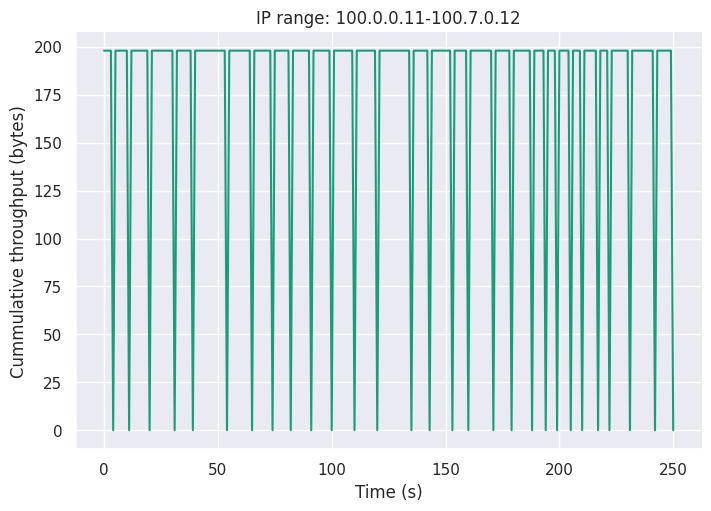

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5), layout='constrained')
df_sorted = merged_df.sort_values('Time', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Time (s)')
plt.title('IP range: 100.0.0.11-100.7.0.12')
_ = plt.ylabel('Cummulative throughput (bytes)')

## Part 2: Time Series Classification

In [ ]:
def create_train_sequences(data, labels, sequence_length):
    X_sequences = []
    y_sequences = []

    for i in range(len(data) - sequence_length + 1):
        X_sequences.append(data[i:i + sequence_length])
        y_sequences.append(labels[i + sequence_length - 1])

    # Replace NaN values with 0
    y = np.array(y_sequences)
    print(np.sum(np.isnan(y)))
    y = np.nan_to_num(y, nan=0)

    return np.array(X_sequences), y


def prepare_train_dataset_univariate(csv_data, sel_data, sel_label, n_classes, sequence_length):
    # _data   = csv_data[[sel_data]].values.reshape(-1, 1)
    # _label  = csv_data[[sel_label]].values

    X, y = create_train_sequences(csv_data[sel_data], csv_data[sel_label], sequence_length)

    # Define the input shape based on sequence length
    input_shape = (X.shape[1], 1)  # Shape: (sequence_length, 1)

    # Reshape X to fit the input shape of the model
    X = X.reshape(-1, *input_shape)

    # Set the label to categorical classes
    y = to_categorical(y, num_classes=n_classes)

    return X, y

def create_test_sequences(data,  sequence_length):
    X_sequences = []

    for i in range(len(data) - sequence_length + 1):
        X_sequences.append(data[i:i + sequence_length])

    return np.array(X_sequences)

def prepare_test_dataset_univariate(csv_data, sel_data, sequence_length):

    X = create_test_sequences(csv_data[sel_data], sequence_length)

    # Define the input shape based on sequence length
    input_shape = (X.shape[1], 1)  # Shape: (sequence_length, 1)

    # Reshape X to fit the input shape of the model
    X = X.reshape(-1, *input_shape)

    return X

Load the dataset

In [ ]:
# location of training test dataset
train_loc = 'dataset/tsc_training_data.csv'
test_loc = 'dataset/test_Y.csv'

#load the training and test dataset
train_data = pd.read_csv(train_loc)
test_data = pd.read_csv(test_loc)

Preprocess the dataset

In [ ]:
### Time Series Univariate Classification
selected_data = 'A'
selected_label = 'A_L'
n_classes = 2
sequence_length = 4

X, y =  prepare_train_dataset_univariate(train_data, selected_data, selected_label, n_classes, sequence_length)
X_test =  prepare_test_dataset_univariate(test_data, selected_data, sequence_length)

0


Define the AI model

In [ ]:
# Define the model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(sequence_length, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(n_classes, activation='softmax')
    ])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Train the model and save the trained model

In [ ]:
# Train the model
history = model.fit(X, y, epochs=10, validation_split=0.2)
# Save the trained model
model.save('dataset/tsc_model.h5')

Epoch 1/10
3500/3500 [==============================] - 14s 4ms/step - loss: 0.4419 - accuracy: 0.9717 - val_loss: 0.0469 - val_accuracy: 0.9854
Epoch 2/10
3500/3500 [==============================] - 8s 2ms/step - loss: 0.0922 - accuracy: 0.9839 - val_loss: 0.0374 - val_accuracy: 0.9884
Epoch 3/10
3500/3500 [==============================] - 9s 3ms/step - loss: 0.0413 - accuracy: 0.9882 - val_loss: 0.0223 - val_accuracy: 0.9895
Epoch 4/10
3500/3500 [==============================] - 9s 3ms/step - loss: 0.0265 - accuracy: 0.9890 - val_loss: 0.0136 - val_accuracy: 0.9932
Epoch 5/10
3500/3500 [==============================] - 10s 3ms/step - loss: 0.0202 - accuracy: 0.9902 - val_loss: 0.0217 - val_accuracy: 0.9857
Epoch 6/10
3500/3500 [==============================] - 8s 2ms/step - loss: 0.0222 - accuracy: 0.9885 - val_loss: 0.0237 - val_accuracy: 0.9884
Epoch 7/10
3500/3500 [==============================] - 9s 3ms/step - loss: 0.0184 - accuracy: 0.9903 - val_loss: 0.0410 - val_accurac

History trained model plots.

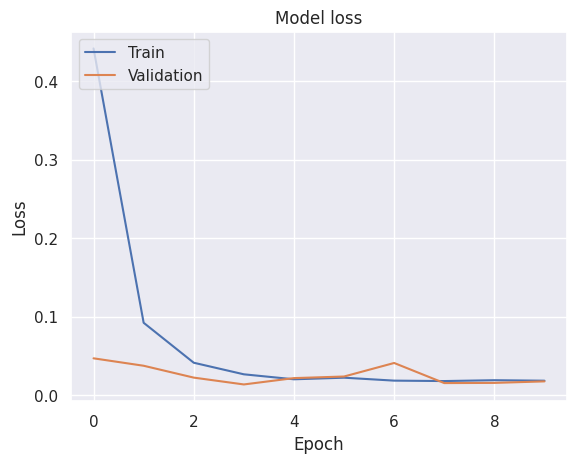

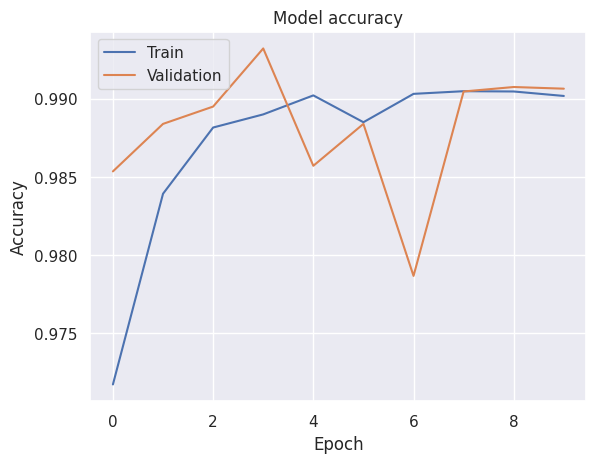

In [ ]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Load the trained model and predict the test data category

## Assignment 📚

### Part 1: Network Traffic Analysis Using Throughput and TDG
- Amongst the 3 scenarios (`pcap_X.csv`, `pcap_Y.csv`, and `pcap_Z.csv`):
- Which of them are classified as a normal traffic and cyber attack traffic? Support your answer with data analysis and plots.
- Identify what are the adversary IP address and attack target IP addresses for each scenario.



### Part 2: Time Series Classification using Machine Learning
- Use the labelled dataset `tsc_training_data.csv` to train a TSC machine learning model.
  
  **Note: You are allowed to test and modify the model and hyperparameters to improve classification performance!.**

  - Implement the trained machine learning model to classify unlabelled time series data of `test_X.csv`, `test_y.csv`, and `test_Z.csv`. Based on the prediction results, answer the following questions:
  - Among all test data, which of them are classified as normal traffic and cyber attack traffic?  
  - Identify the impact of cyber attack on the time series traffic. Support your answer with data analysis and plots.

### Part 3: Comparative analysis

- Provide a comparative analysis of the two methods (TDG and TSC) used in Parts 1 and 2.
- List the advantages and drawbacks for each method.

- Based on the lectures and assignment
provide suggestions/ideas on how to detect anomalous traffic in power grid operational technology networks?